# Modeling — MAGIC Gamma Telescope Dataset

---
**Goal:** Train and compare 4 ML models:
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost
4. MLP Neural Network

**Metrics:** ROC-AUC, F1-score, Precision, Recall, Accuracy

## 1. Imports

In [2]:
pip install xgboost


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 222.6 kB/s eta 0:07:37
   ---------------------------------------- 0.0/101.7 MB 220.2 kB/s eta 0:07:42
   ---------------------------------------- 0.1/101.7 MB 328.2 kB/s eta 0:05:10
   ---------------------------------------- 0.1/101.7 MB 438.1 kB/s eta 0:03:52
   ---------------------------------------- 0.1/101.7 MB 481.4 kB/s eta 0:03:31
   ---------------------------------------- 0.2/101.7 MB 761.1 kB/s eta 0:02:14
   ---------------------------------------- 0.3/101.7 MB 806.1 kB/s eta 0:02:06
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:18
   -----------

In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

import joblib, os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Imports OK')

✅ Imports OK


## 2. Load Preprocessed Data

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (15216, 10), X_test: (3804, 10)
y_train: (15216,), y_test: (3804,)


## 3. Define Models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        random_state=42
    )
}

print('Models defined:')
for name in models:
    print(f'  • {name}')

Models defined:
  • Logistic Regression
  • Random Forest
  • XGBoost
  • MLP Neural Network


## 4. Train & Evaluate All Models

In [6]:
os.makedirs('../models', exist_ok=True)

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    })
    
    # Save model
    joblib.dump(model, f'../models/{name.replace(" ", "_").lower()}.pkl')
    trained_models[name] = model
    print('✅')

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print('\n', results_df.round(4).to_string())

Training Logistic Regression... ✅
Training Random Forest... ✅
Training XGBoost... ✅
Training MLP Neural Network... ✅

                      Accuracy      F1  Precision  Recall  ROC-AUC
Model                                                            
XGBoost                0.8862  0.9151     0.8858  0.9465   0.9387
Random Forest          0.8859  0.9148     0.8869  0.9444   0.9374
MLP Neural Network     0.8801  0.9118     0.8714  0.9562   0.9328
Logistic Regression    0.7836  0.8439     0.7929  0.9019   0.8313


## 5. Results Table

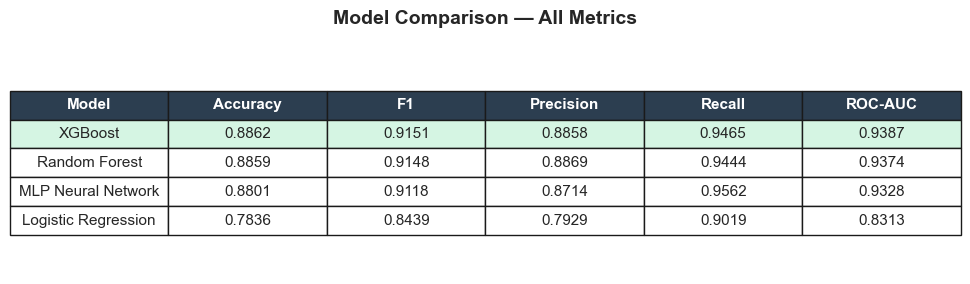

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table_data = results_df.round(4).reset_index()
col_labels = table_data.columns.tolist()
cell_data  = table_data.values.tolist()

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)

# Highlight header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best model row
for j in range(len(col_labels)):
    table[1, j].set_facecolor('#d5f5e3')

plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bar Chart — Metric Comparison

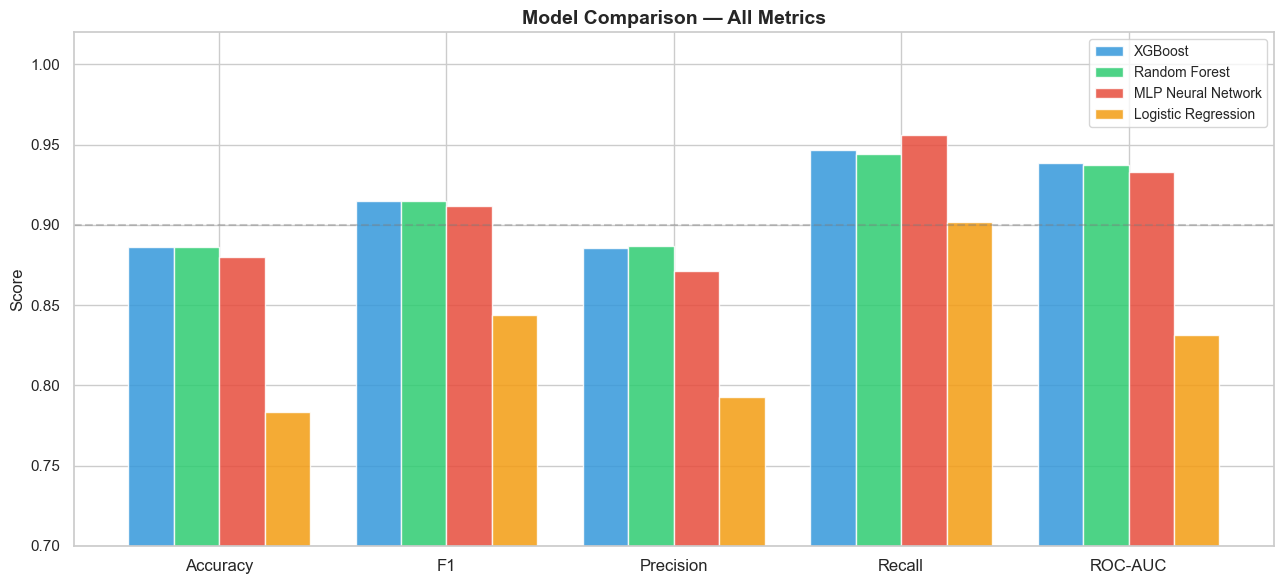

In [8]:
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, label='0.9 threshold')

plt.tight_layout()
plt.savefig('../data/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ROC Curves

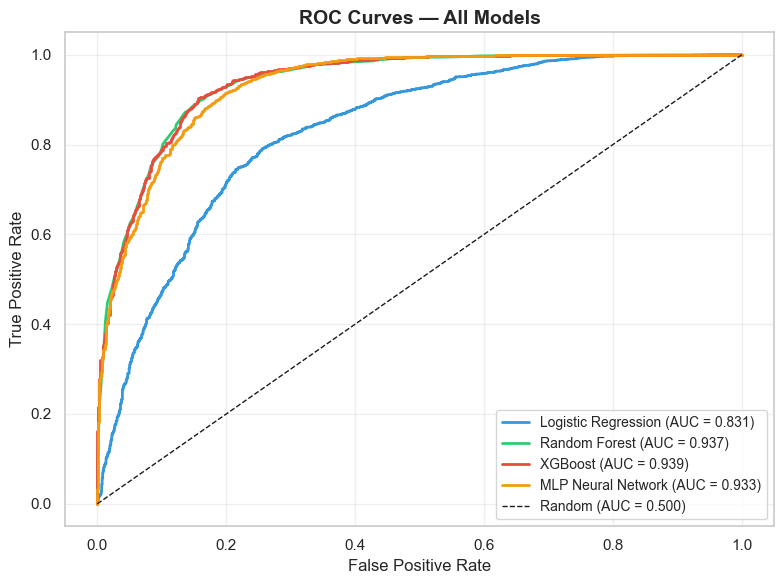

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

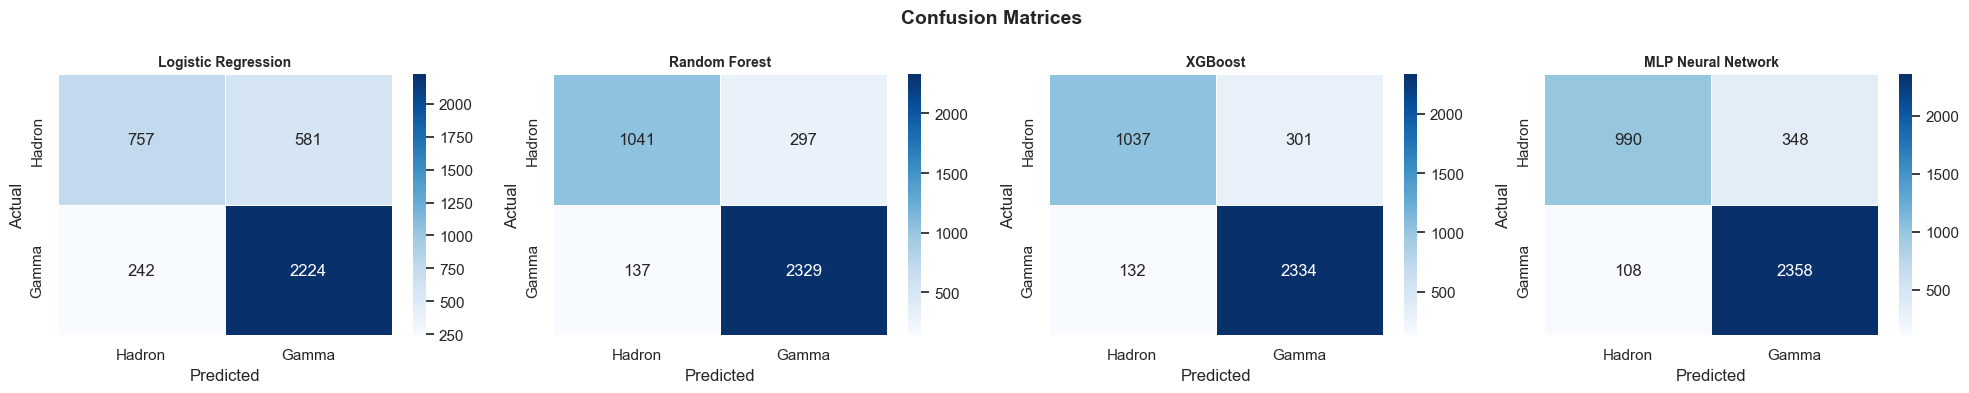

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model), color in zip(axes, trained_models.items(), colors):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Hadron', 'Gamma'],
                yticklabels=['Hadron', 'Gamma'])
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance (Random Forest & XGBoost)

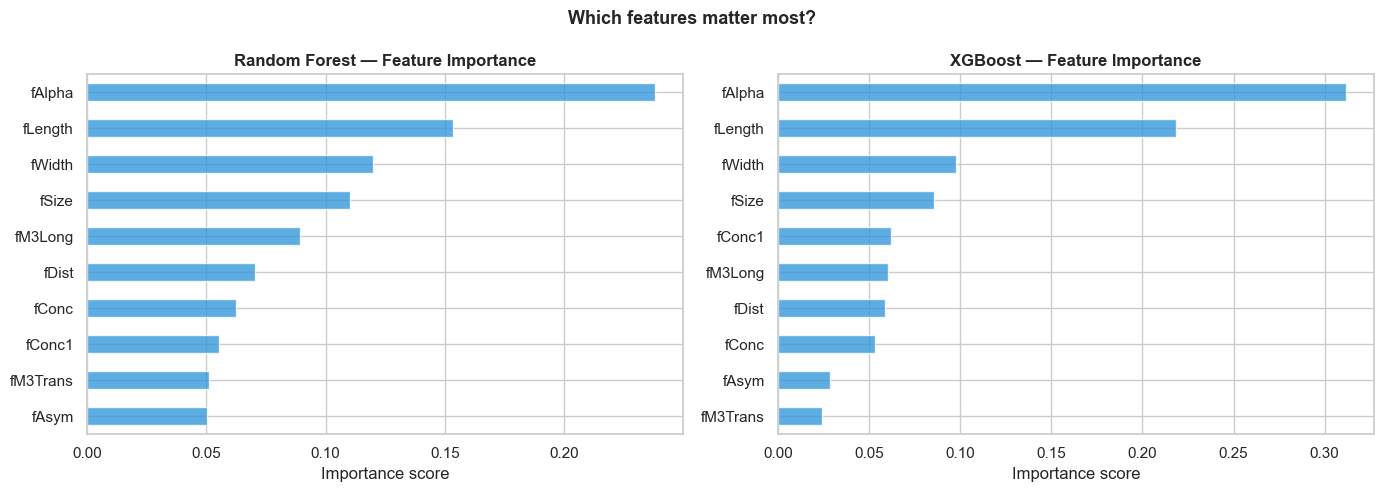

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models[name]
    importances = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    importances.plot.barh(ax=ax, color='#3498db', alpha=0.8)
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance score')

plt.suptitle('Which features matter most?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Best Model — Detailed Report

In [12]:
best_name = results_df.index[0]
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print(f'🏆 Best model: {best_name}')
print(f'   ROC-AUC: {results_df.loc[best_name, "ROC-AUC"]:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Hadron (0)', 'Gamma (1)']))

🏆 Best model: XGBoost
   ROC-AUC: 0.9387

Classification Report:
              precision    recall  f1-score   support

  Hadron (0)       0.89      0.78      0.83      1338
   Gamma (1)       0.89      0.95      0.92      2466

    accuracy                           0.89      3804
   macro avg       0.89      0.86      0.87      3804
weighted avg       0.89      0.89      0.88      3804



## 11. Summary

In [13]:
print('=' * 55)
print('  MODELING SUMMARY')
print('=' * 55)
print(results_df.round(4).to_string())
print()
print(f'🏆 Best model: {results_df.index[0]}')
print(f'   ROC-AUC:  {results_df["ROC-AUC"].max():.4f}')
print(f'   F1-score: {results_df.loc[results_df.index[0], "F1"]:.4f}')
print()
print('Key observations:')
print('  • Tree-based models (RF, XGBoost) outperform linear baseline')
print('  • fAlpha confirmed as top feature by both RF and XGBoost')
print('  • All models significantly better than random (AUC > 0.5)')
print('=' * 55)

  MODELING SUMMARY
                     Accuracy      F1  Precision  Recall  ROC-AUC
Model                                                            
XGBoost                0.8862  0.9151     0.8858  0.9465   0.9387
Random Forest          0.8859  0.9148     0.8869  0.9444   0.9374
MLP Neural Network     0.8801  0.9118     0.8714  0.9562   0.9328
Logistic Regression    0.7836  0.8439     0.7929  0.9019   0.8313

🏆 Best model: XGBoost
   ROC-AUC:  0.9387
   F1-score: 0.9151

Key observations:
  • Tree-based models (RF, XGBoost) outperform linear baseline
  • fAlpha confirmed as top feature by both RF and XGBoost
  • All models significantly better than random (AUC > 0.5)
